# Taller análisis descriptivo de variables cualitativas

Estudiante: Hasber Malpica Barroso

Se va a trabajar con un dataset que contiene información sobre incidentes de tránsito en Medellín con víctimas.

Cárguelo y verifique que se haya cargado correctamente.

In [93]:
import pandas as pd

df = pd.read_csv("/content/sample_data/Accidentes de tránsito en Medellín.csv")
df.head()

,Fecha_incidente,Gravedad_victima,Clase_incidente,Sexo,Condicion,Grupo_edad,Comuna,Barrio,Dia_semana,Mes,Año
0,2014-01-01,Heridos,Otro,M,Motociclista,10 - 19,04 - Aranjuez,Manrique Central No. 1,Miércoles,Enero,2014
1,2014-01-01,Heridos,Atropello,M,Motociclista,20 - 29,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
2,2014-01-01,Heridos,Atropello,F,Peatón,10 - 19,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
3,2014-01-01,Heridos,Atropello,M,Motociclista,10 - 19,16 - Belén,Las Mercedes,Miércoles,Enero,2014
4,2014-01-01,Heridos,Atropello,M,Peatón,30 - 39,16 - Belén,Las Mercedes,Miércoles,Enero,2014


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235843 entries, 0 to 235842
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Fecha_incidente   235843 non-null  object
 1   Gravedad_victima  235843 non-null  object
 2   Clase_incidente   235843 non-null  object
 3   Sexo              233366 non-null  object
 4   Condicion         235843 non-null  object
 5   Grupo_edad        233309 non-null  object
 6   Comuna            214117 non-null  object
 7   Barrio            213961 non-null  object
 8   Dia_semana        235843 non-null  object
 9   Mes               235843 non-null  object
 10  Año               235843 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 19.8+ MB


La variable "Fecha_incidente" debe convertirse a dato de tiempo.

Excluya los datos del año 2021.

In [95]:
df['Fecha_incidente'] = pd.to_datetime(
    df['Fecha_incidente'],
    )
df = df[df['Fecha_incidente'].dt.year != 2021]
df.head()


,Fecha_incidente,Gravedad_victima,Clase_incidente,Sexo,Condicion,Grupo_edad,Comuna,Barrio,Dia_semana,Mes,Año
0,2014-01-01,Heridos,Otro,M,Motociclista,10 - 19,04 - Aranjuez,Manrique Central No. 1,Miércoles,Enero,2014
1,2014-01-01,Heridos,Atropello,M,Motociclista,20 - 29,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
2,2014-01-01,Heridos,Atropello,F,Peatón,10 - 19,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
3,2014-01-01,Heridos,Atropello,M,Motociclista,10 - 19,16 - Belén,Las Mercedes,Miércoles,Enero,2014
4,2014-01-01,Heridos,Atropello,M,Peatón,30 - 39,16 - Belén,Las Mercedes,Miércoles,Enero,2014


De acuerdo a lo visto en clase, indique qué tipo de variable es cada una de las que están en el DataFrame.

Convierta a "category" las variables categóricas, cuidando que las variables nominales y ordinales queden correctamente convertidas.

Fecha_incidente: Cuantitativa continua

Gravedad_victima: Cualitativa nominal

Clase_incidente: Cualitativa nominal

Sexo: Cualitativa nominal

Condicion: Cualitativa nominal

Grupo edad: Cualitativa ordinal

Comuna Cualitativa nominal

Barrio: Cualitativa nominal

Dia_semana: Cualitativa ordinal

Mes: cualitativa ordinal

Año: Cuantitativa discreta de intervalo


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214116 entries, 0 to 214115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Fecha_incidente   214116 non-null  datetime64[ns]
 1   Gravedad_victima  214116 non-null  object        
 2   Clase_incidente   214116 non-null  object        
 3   Sexo              212482 non-null  object        
 4   Condicion         214116 non-null  object        
 5   Grupo_edad        211871 non-null  object        
 6   Comuna            195177 non-null  object        
 7   Barrio            195036 non-null  object        
 8   Dia_semana        214116 non-null  object        
 9   Mes               214116 non-null  object        
 10  Año               214116 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 19.6+ MB


In [97]:
df1 = df.copy()

In [98]:
from pandas.api.types import CategoricalDtype

df1['Gravedad_victima'] = df1['Gravedad_victima'].astype('category')
df1['Clase_incidente'] = df1['Clase_incidente'].astype('category')
df1['Sexo'] = df1['Sexo'].astype('category')
df1['Condicion'] = df1['Condicion'].astype('category')
df1['Comuna'] = df1['Comuna'].astype('category')
df1['Barrio'] = df1['Barrio'].astype('category')

dia_semana_order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
dia_semana_dtype = CategoricalDtype(categories=dia_semana_order, ordered=True)
df1['Dia_semana'] = df1['Dia_semana'].astype(dia_semana_dtype)

mes_order = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
mes_dtype = CategoricalDtype(categories=mes_order, ordered=True)
df1['Mes'] = df1['Mes'].astype(mes_dtype)

grupo_edad_order = sorted(df1['Grupo_edad'].dropna().unique().tolist())
grupo_edad_dtype = CategoricalDtype(categories=grupo_edad_order, ordered=True)
df1['Grupo_edad'] = df1['Grupo_edad'].astype(grupo_edad_dtype)

df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214116 entries, 0 to 214115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Fecha_incidente   214116 non-null  datetime64[ns]
 1   Gravedad_victima  214116 non-null  category      
 2   Clase_incidente   214116 non-null  category      
 3   Sexo              212482 non-null  category      
 4   Condicion         214116 non-null  category      
 5   Grupo_edad        211871 non-null  category      
 6   Comuna            195177 non-null  category      
 7   Barrio            195036 non-null  category      
 8   Dia_semana        214116 non-null  category      
 9   Mes               214116 non-null  category      
 10  Año               214116 non-null  int64         
dtypes: category(9), datetime64[ns](1), int64(1)
memory usage: 7.0 MB


Identifique qué variable(s) tienen alta cardinalidad. Excluya esta(s) de los análisis posteriores.

In [99]:
for col in df1.select_dtypes(include='category').columns:
    num_unique_categories = df1[col].nunique()
    print(f"Variable '{col}': {num_unique_categories} categorías únicas")

Variable 'Gravedad_victima': 2 categorías únicas
Variable 'Clase_incidente': 6 categorías únicas
Variable 'Sexo': 2 categorías únicas
Variable 'Condicion': 7 categorías únicas
Variable 'Grupo_edad': 9 categorías únicas
Variable 'Comuna': 21 categorías únicas
Variable 'Barrio': 418 categorías únicas
Variable 'Dia_semana': 7 categorías únicas
Variable 'Mes': 12 categorías únicas


In [100]:
df1 = df1.drop(columns=['Barrio'])
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214116 entries, 0 to 214115
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Fecha_incidente   214116 non-null  datetime64[ns]
 1   Gravedad_victima  214116 non-null  category      
 2   Clase_incidente   214116 non-null  category      
 3   Sexo              212482 non-null  category      
 4   Condicion         214116 non-null  category      
 5   Grupo_edad        211871 non-null  category      
 6   Comuna            195177 non-null  category      
 7   Dia_semana        214116 non-null  category      
 8   Mes               214116 non-null  category      
 9   Año               214116 non-null  int64         
dtypes: category(8), datetime64[ns](1), int64(1)
memory usage: 6.5 MB


Haga las tablas de frecuencias porcentuales de todas las variables categóricas.

Para cada variable, indique cuál es la categoría más frecuente y cuál la menos frecuente.

Identifique qué variables presentan categorías atípicas. Indique los nombres de las categorías atípicas.

In [101]:
for col in df1.select_dtypes(include='category').columns:
    print(f"\nTabla de Frecuencia Porcentual para '{col}':")
    display(100 * df1[col].value_counts(normalize=True).round(4))


Tabla de Frecuencia Porcentual para 'Gravedad_victima':


,proportion
Gravedad_victima,
Heridos,99.17
Muertos,0.83



Tabla de Frecuencia Porcentual para 'Clase_incidente':


,proportion
Clase_incidente,
Choque,43.97
Otro,17.23
Atropello,16.96
Caida Ocupante,15.23
Volcamiento,6.59
Incendio,0.01



Tabla de Frecuencia Porcentual para 'Sexo':


...

,proportion
Comuna,
10 - La Candelaria,17.23
05 - Castilla,10.75
11 - Laureles Estadio,9.34
07 - Robledo,7.69
04 - Aranjuez,6.83
15 - Guayabal,6.80
16 - Belén,6.37
14 - El Poblado,5.73
03 - Manrique,4.39



Tabla de Frecuencia Porcentual para 'Dia_semana':


,proportion
Dia_semana,
Miércoles,14.83
Viernes,14.83
Martes,14.69
Jueves,14.66
Sábado,14.56
Lunes,14.38
Domingo,12.05



Tabla de Frecuencia Porcentual para 'Mes':


,proportion
Mes,
Agosto,8.94
Septiembre,8.92
Octubre,8.65
Julio,8.48
Marzo,8.48
Diciembre,8.46
Febrero,8.44
Noviembre,8.18
Mayo,8.05


Para las variables con mayor frencuencia y menor frecuencia son:

Gravedad_victima-- Mayor => Heridos, la menor => Muertos

Clase_incidente--- Mayor => Choque, la menor => Incendio

Sexo-------------- Mayor => M, la menor => H

Condicion--------- Mayor => Motociclista, la menor => Acompañante de motocicleta

Grupo_edad-------- Mayor => 20 - 29, la menor => 80 o más

Comuna------------ Mayor => La Candelaria, la menor => Corregimiento de San Sebastián de Palmitas

Dia_semana-------- Mayor => Miércoles, la menor => Domingo

Mes--------------- Mayor => Agosto, la menor => Abril


Identificando categorías atípicas (frecuencia porcentual < 1%):

Variable 'Gravedad_victima' tiene las siguientes categorías atípicas:
  - Muertos (0.83%) parte del total de las 100)

Variable 'Clase_incidente' tiene las siguientes categorías atípicas:
  - Incendio (0.01%) parte del total de las 100)

Variable 'Grupo_edad' tiene las siguientes categorías atípicas:
  - 80 o más (0.64%) parte del total de las 100)
  
Variable 'Comuna' tiene las siguientes categorías atípicas:
  - 70 - Corregimiento de Altavista (0.34%) parte del total de las 100)
  - 90 - Corregimiento de Santa Elena (0.28%) parte del total de las 100)
  - 50 - Corregimiento de San Sebastián de Palmitas (0.01%) parte del total de las 100)

Para las variables nominales, haga un gráfico de barras horizontales de la tabla de frecuencia relativa, ordenados de forma descendente.

Para las variables ordinales, haga un gráfico de barras verticales de la tabla de frecuencia relativa, ordenados de acuerdo al orden de las categorías.


--- Gráficos de Frecuencia Relativa para Variables Nominales ---



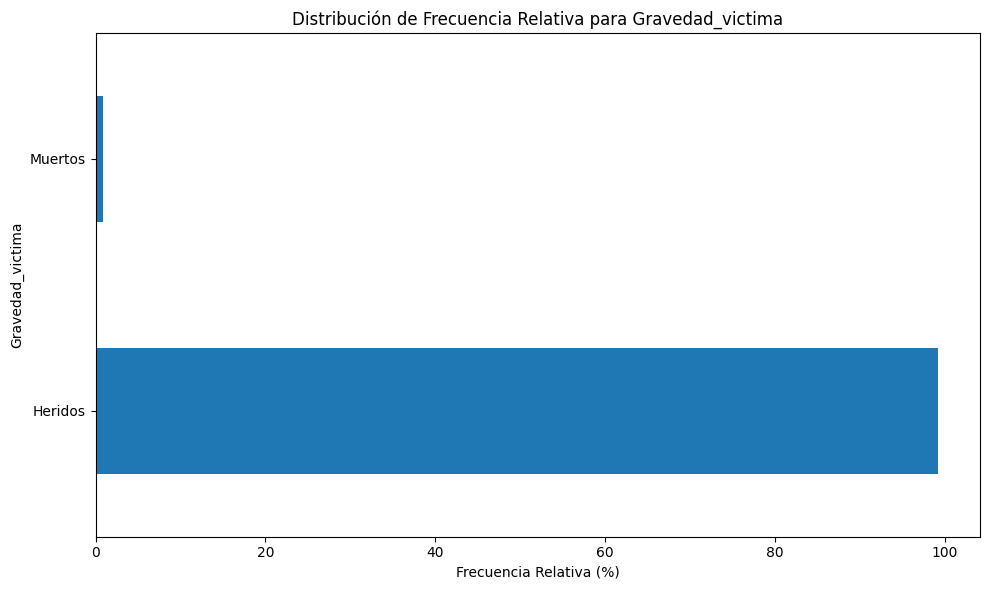

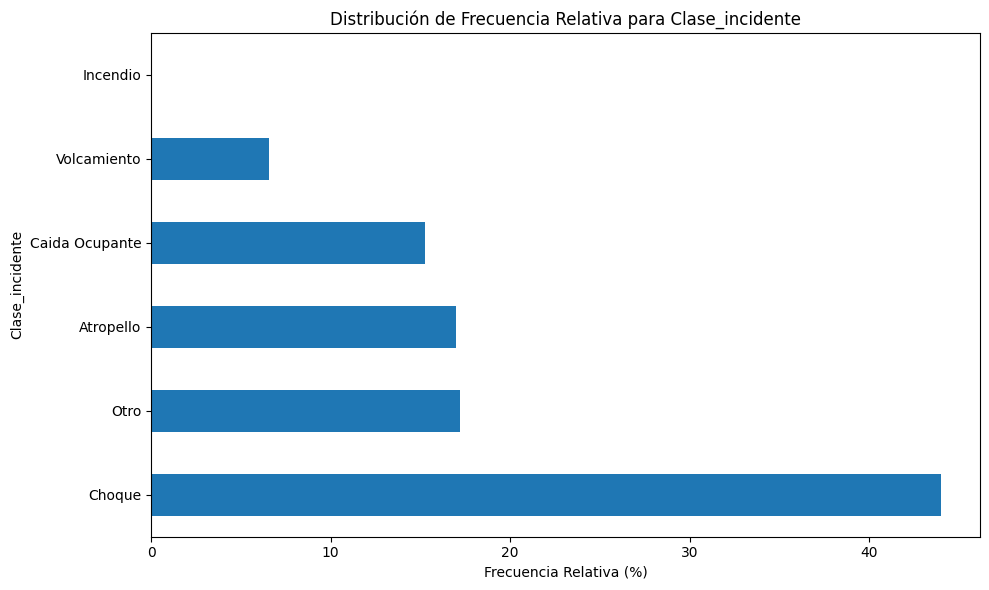

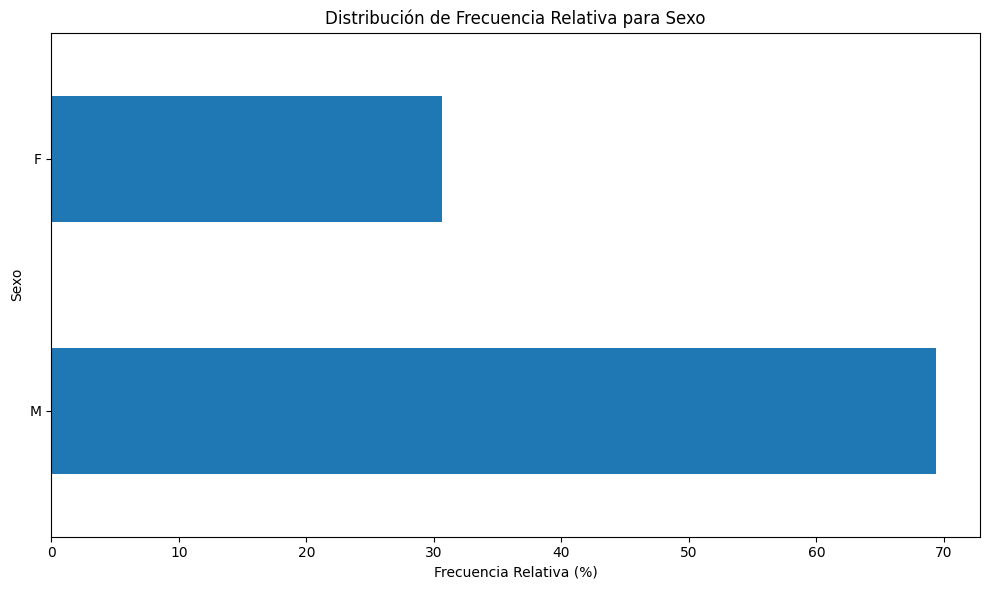

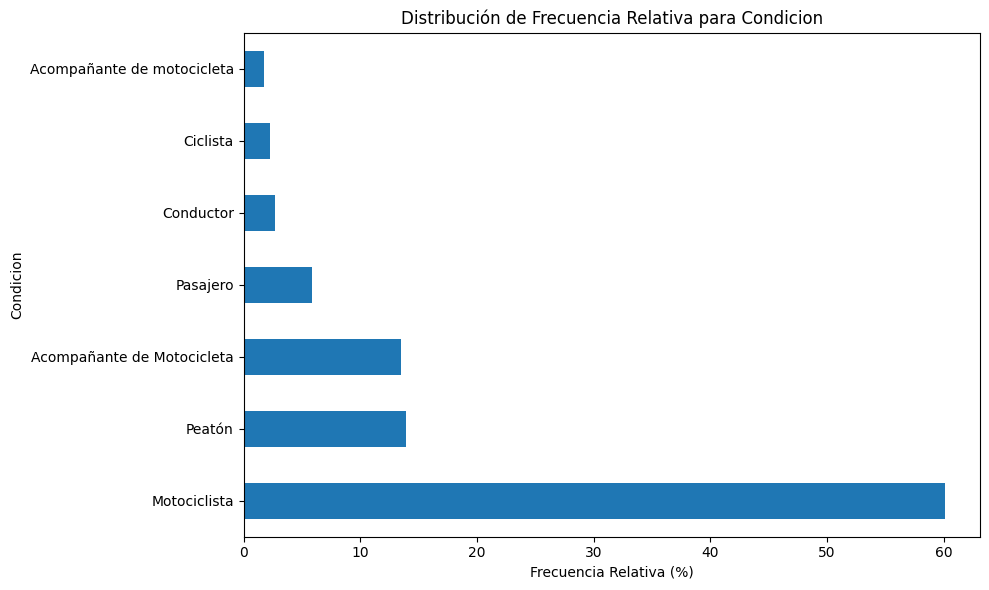

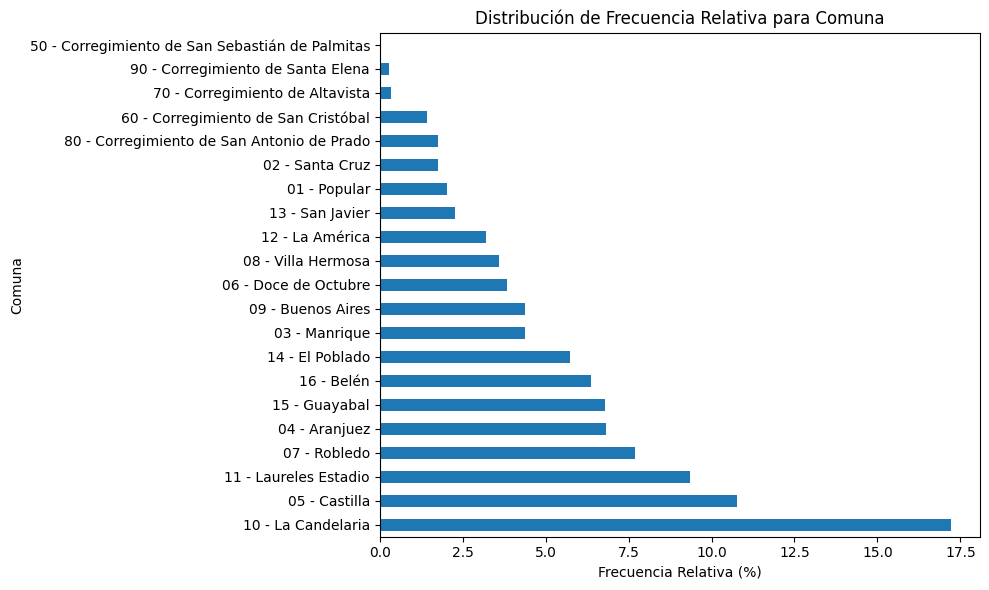


--- Gráficos de Frecuencia Relativa para Variables Ordinales ---



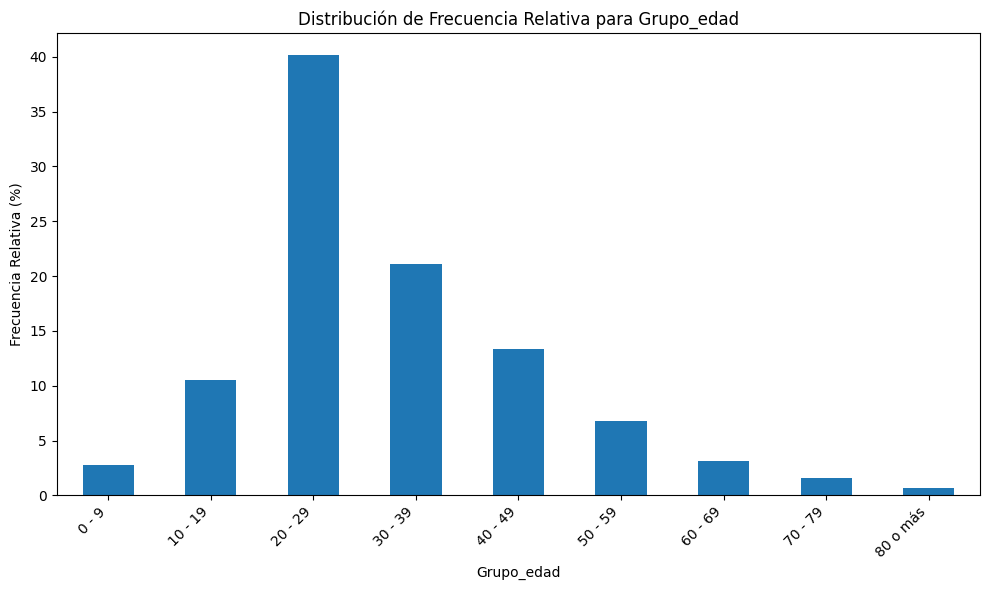

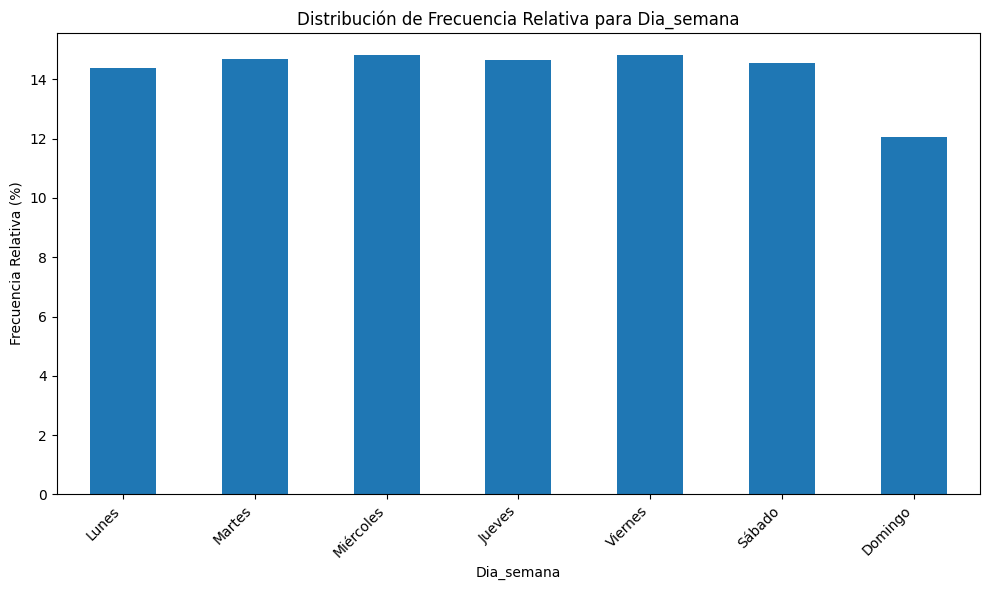

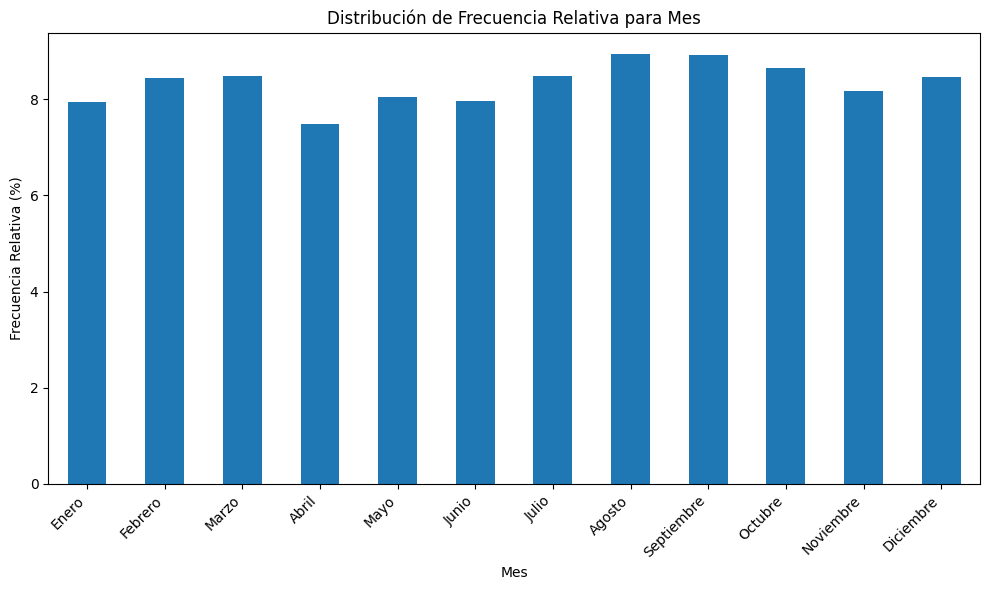

In [102]:
import matplotlib.pyplot as plt

nominal_variables = ['Gravedad_victima', 'Clase_incidente', 'Sexo', 'Condicion', 'Comuna']
ordinal_variables = ['Grupo_edad', 'Dia_semana', 'Mes']

print("\n--- Gráficos de Frecuencia Relativa para Variables Nominales ---\n")
for col in nominal_variables:
    plt.figure(figsize=(10, 6))

    (df1[col].value_counts(normalize=True) * 100).plot(kind='barh')
    plt.title(f'Distribución de Frecuencia Relativa para {col}')
    plt.xlabel('Frecuencia Relativa (%)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

print("\n--- Gráficos de Frecuencia Relativa para Variables Ordinales ---\n")
for col in ordinal_variables:
    plt.figure(figsize=(10, 6))

    (df1[col].value_counts(normalize=True, sort=False) * 100).plot(kind='bar')
    plt.title(f'Distribución de Frecuencia Relativa para {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia Relativa (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Para las variables ordinales, haga un gráfico de barras vertical de la tabla de frecuencia acumulada, ordenada de acuerdo al orden de las categorías.

Para las variables ordinales, calcule la mediana, y los quartiles 1, 2 y 3.


--- Gráficos de Frecuencia Acumulada para Variables Ordinales ---



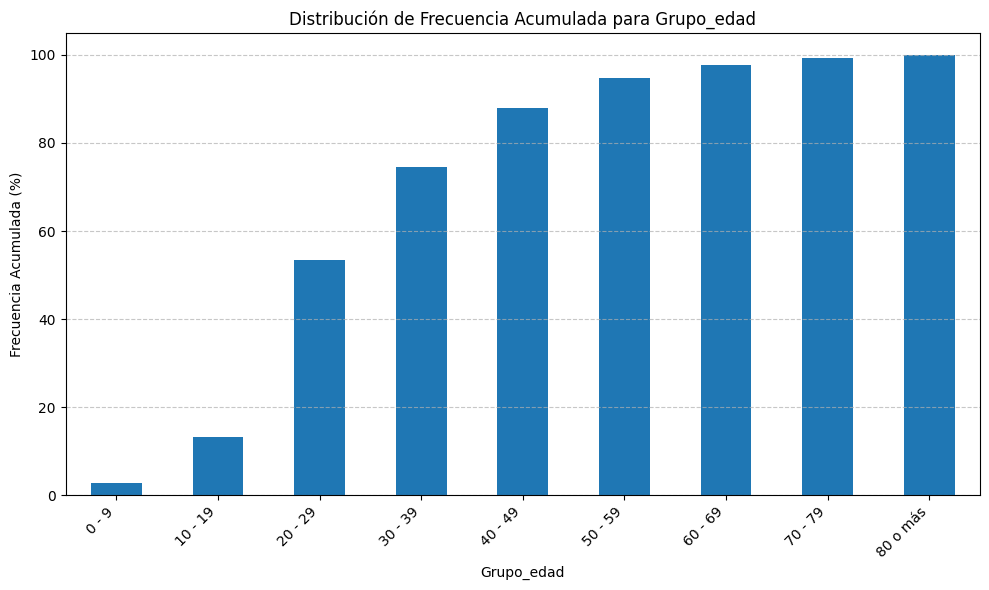

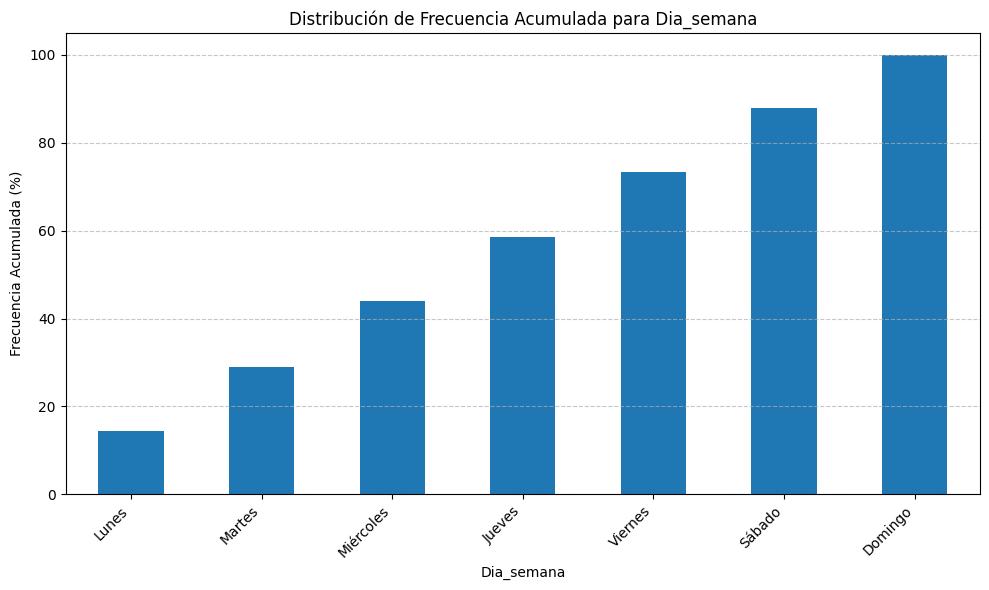

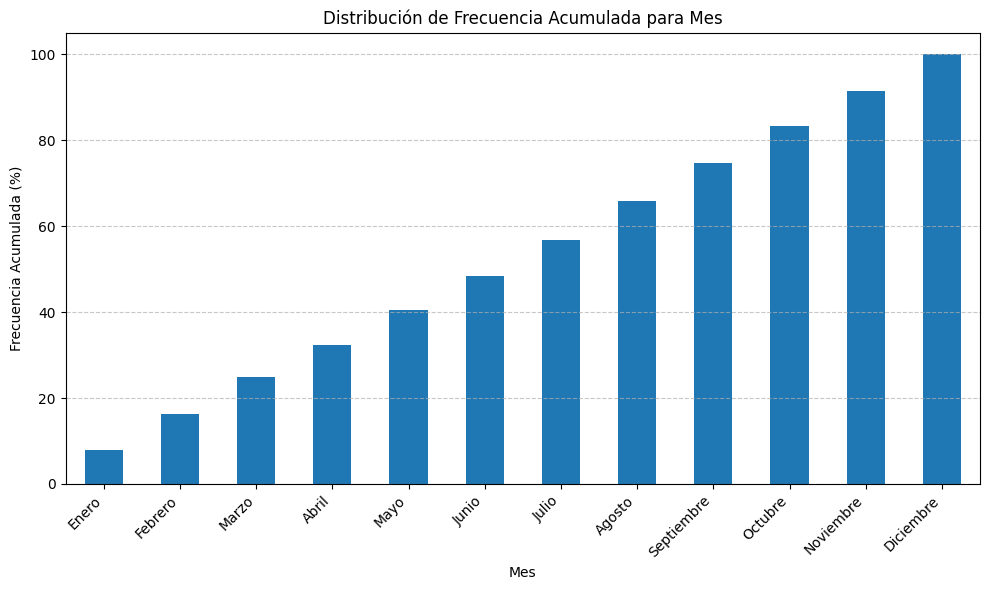

In [103]:
import matplotlib.pyplot as plt
import pandas as pd

ordinal_variables = ['Grupo_edad', 'Dia_semana', 'Mes']

print("\n--- Gráficos de Frecuencia Acumulada para Variables Ordinales ---\n")
for col in ordinal_variables:
    plt.figure(figsize=(10, 6))

    frequencies_ordered = df1[col].value_counts(normalize=True).reindex(df1[col].cat.categories, fill_value=0)

    cumulative_freq_perc = frequencies_ordered.cumsum() * 100

    cumulative_freq_perc.plot(kind='bar')
    plt.title(f'Distribución de Frecuencia Acumulada para {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia Acumulada (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



In [104]:
print("\n--- Cuartiles y Mediana para Variables Ordinales ---\n")
for col in ordinal_variables:
    print(f"Variable: {col}")

    q_values = df1[col].cat.codes.quantile([0.25, 0.5, 0.75])
    q1_category = df1[col].cat.categories[int(q_values.loc[0.25])]
    median_category = df1[col].cat.categories[int(q_values.loc[0.5])]
    q3_category = df1[col].cat.categories[int(q_values.loc[0.75])]

    print(f"  Q1 (25%): {q1_category}")
    print(f"  Mediana (Q2, 50%): {median_category}")
    print(f"  Q3 (75%): {q3_category}")
    print("--------------------------------------------------")


--- Cuartiles y Mediana para Variables Ordinales ---

Variable: Grupo_edad
  Q1 (25%): 20 - 29
  Mediana (Q2, 50%): 20 - 29
  Q3 (75%): 40 - 49
--------------------------------------------------
Variable: Dia_semana
  Q1 (25%): Martes
  Mediana (Q2, 50%): Jueves
  Q3 (75%): Sábado
--------------------------------------------------
Variable: Mes
  Q1 (25%): Abril
  Mediana (Q2, 50%): Julio
  Q3 (75%): Octubre
--------------------------------------------------
